# Dataset-v2 inspection & explainer

This notebook has two jobs:

1. **Explain** how this dataset is built: where it lives, what pipeline stage
   produced each file, and what every per-token / per-rollout / per-prompt
   column means.
2. **Explore** the dataset as it exists *right now*: verify what's actually
   present vs. still being generated (and give the exact command to produce
   whatever is missing), look at domain/split composition, degeneration-rate
   statistics across all three labeling signals, and browse individual
   prompt/rollout generations interactively.

This notebook is read-only with respect to the dataset itself -- it never
writes into `output_root`. The only files it writes are exported
prompt/rollout figures under `notebooks/figures/` (Section 6).

## 1. Where this dataset lives, and how it's built

### Storage

- **`output_root`** (the dataset itself -- final, shared, group-readable):
  `/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_full_scale/`.
  Group `infra01`; teammates with capstor-store access under that group can
  read it directly.
- **`work_root`** (scratch, resumable intermediates -- *not* the dataset):
  `/capstor/scratch/cscs/mdenegri/degeneration-probe/dataset_v2_full_scale_work/`.
  Per-row partial JSON files written during generation, consolidated into the
  shards under `output_root` once a domain finishes. Safe to delete once a
  domain's shard is fully consolidated (Section 3 checks this).

### Folder structure under `output_root`

```
dataset_v2_full_scale/
    manifest.json                        # git commit + full config + model config for this build
    prompts/prompts.parquet              # every prompt: prompt_id, domain, source_dataset,
                                          # source_row_id, prompt_text, held_out_domain
    generations/<domain>/shard_00000.parquet   # one row per (prompt_id, rollout_idx):
                                                # generated_text, generated_token_ids,
                                                # per_token_entropy, num_tokens, stop_reason, seed
    labels/<domain>/shard_00000.parquet        # one row per (prompt_id, rollout_idx):
                                                # repetition_score, entropy (per-token arrays) +
                                                # lrs_* -- one exact repeated-substring match per
                                                # rollout (length/score/positions/gap/period/etc),
                                                # not a per-token array -- see Section 6
    prompt_stats/prompt_stats.parquet          # one row per prompt_id, aggregated across its
                                                # n_rollouts_per_prompt rollouts (Section 5)
    activations/<domain>/<prompt_id>/rollout_<k>.safetensors   # cached hidden states
    activations/manifest.parquet               # which (prompt_id, rollout_idx) have a cached activation
    llm_judge/                                 # LLM-judge calibration labels
    splits/{train,val,test_indomain,test_heldout_domains}.jsonl  # prompt_id -> split, one JSON obj/line
```

`domain` always means one specific *source* (e.g. `deepmath_103k`, `aime_2025`),
never the coarser in-domain/held-out split -- see
`degeneration_probe/dataset_gen/paths.py`'s module docstring. Currently
configured: 4 in-domain sources (`deepmath_103k`, `numinamath_1_5`,
`if_sft_data_verified`, `llama_nemotron`) used for train/val/test_indomain,
plus 2 sources held out **entirely** from training for zero-shot testing
(`medical_o1`, `aime_2025`) that only ever appear in `test_heldout_domains`.

### Pipeline stages, in order (each depends on the previous stage's output)

1. **`build_prompts.py`** -- samples prompts from each configured HF source,
   assigns `prompt_id` / `domain` / `held_out_domain`, writes
   `prompts.parquet` + the 4 split files. CPU-only, run directly.
2. **`generate.py`** -- for each domain, runs `n_rollouts_per_prompt` (10)
   rollouts x every prompt through the model (`max_new_tokens=4096`,
   `temperature=0.7`, `top_p=0.9`), writes `generations/<domain>/shard_00000.parquet`.
   **Needs a GPU** -- runs as a SLURM job via `cluster/generate_full_scale.sbatch`,
   one independent job chain per domain (resumable -- a chain that hits the
   12h wall-clock limit just picks up where it left off in its next wave).
3. **`label.py`** -- for each already-generated domain, computes the
   per-token repetition/entropy signals plus the whole-rollout LRS match,
   and aggregates them into `prompt_stats.parquet`. CPU-only, run directly,
   takes seconds per domain. **Gotcha:** it overwrites `prompt_stats.parquet`
   wholesale with exactly the domains passed via `--domains` on that
   invocation (not merged with a previous run) -- always pass every
   currently-fully-generated domain together, not just the newly-finished
   ones. Section 3 accounts for this when it prints the recreate command.
4. **`cache_activations.py`** -- *(deferred)* re-runs a teacher-forced
   forward pass per rollout to cache per-layer hidden states. Needs a GPU.
5. **LLM-judge labeling** -- *(deferred, not implemented yet)*.

### Dependencies to run any of this yourself

- Repo checked out at `/iopsstor/scratch/cscs/$USER/degeneration-probe`, at
  the exact commit recorded in `manifest.json`'s `pipeline_git_commit`
  (Section 2 reads and prints it).
- **CPU-only steps** (`build_prompts.py`, `label.py`, this notebook): the
  repo's `uv`-managed virtualenv at `.venv/` -- run `uv sync` from the repo
  root if it doesn't exist yet. This notebook additionally needs `ipywidgets`
  for Section 7's interactive cell (already pinned in `pyproject.toml`).
- **GPU steps** (`generate.py`, `cache_activations.py`): submitted through
  SLURM using the container image pinned in `cluster/env.toml`, plus a valid
  HF token at `~/keys/.hf_token` (needed for gated/rate-limited HF datasets
  and the model itself).

## 2. Setup

In [40]:
import json
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from degeneration_probe.dataset_gen import paths
from degeneration_probe.dataset_gen import label as label_module
from degeneration_probe.dataset_gen.config import PilotDatasetConfig
from degeneration_probe.dataset_gen.manifest import read_manifest

pd.set_option("display.max_colwidth", 120)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Point this at configs/dataset_gen/pilot_v1.yaml instead to inspect the
# earlier 370-prompt / 1024-token pilot.
CONFIG_PATH = REPO_ROOT / "configs" / "dataset_gen" / "full_scale_v1.yaml"
config = PilotDatasetConfig.from_yaml(CONFIG_PATH)

DOMAINS = sorted(paths.configured_domain_names(config))
SPLIT_NAMES = ["train", "val", "test_indomain", "test_heldout_domains"]

print(f"Config           : {CONFIG_PATH.relative_to(REPO_ROOT)}")
print(f"output_root      : {config.output_root}")
print(f"Configured domains ({len(DOMAINS)}): {DOMAINS}")

Config           : configs/dataset_gen/full_scale_v1.yaml
output_root      : /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/dataset_v2_full_scale
Configured domains (6): ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5']


In [41]:
manifest_file = paths.manifest_path(config)
if manifest_file.exists():
    manifest = read_manifest(manifest_file)
    print("manifest.json: OK")
    print(f"  pipeline_git_commit : {manifest['pipeline_git_commit']}")
    print(f"  created_at          : {manifest['created_at']}")
    print(f"  model_config        : {manifest['model_config']}")
else:
    cfg_rel = CONFIG_PATH.relative_to(REPO_ROOT)
    print("manifest.json: MISSING. To write it, run from the repo root (.venv, CPU-only):")
    print()
    print("  .venv/bin/python -c \"")
    print("from degeneration_probe.dataset_gen.config import PilotDatasetConfig")
    print("from degeneration_probe.dataset_gen.manifest import write_manifest")
    print(f"config = PilotDatasetConfig.from_yaml('{cfg_rel}')")
    print("write_manifest(config)\"")

manifest.json: OK
  pipeline_git_commit : b901ae1d38ed53e06602e9ab5df3c35f3bb1f86c
  created_at          : 2026-07-06T16:01:44.192556+00:00
  model_config        : {'hidden_size': 4096, 'num_hidden_layers': 32, 'vocab_size': 131072, 'model_type': 'apertus'}


## 3. Completeness check

Verifies every stage's output actually exists and is fully populated, and
prints the exact command to (re)build anything that's missing or partial.
Nothing in this section modifies the dataset.

In [42]:
def _expected_prompt_count(config, domain):
    for source in [*config.in_domain_sources, *config.held_out_sources]:
        if source["name"] == domain:
            return source["n_prompts"]
    raise KeyError(domain)


cfg_rel = CONFIG_PATH.relative_to(REPO_ROOT)

prompts_ok = paths.prompts_path(config).exists()
splits_ok = all(paths.split_path(config, name).exists() for name in SPLIT_NAMES)

print(f"[{'OK' if prompts_ok else 'MISSING'}] prompts.parquet")
print(f"[{'OK' if splits_ok else 'MISSING'}] splits/*.jsonl")
if not (prompts_ok and splits_ok):
    print()
    print("To (re)build prompts + splits, run from the repo root (.venv, CPU-only):")
    print(f"  .venv/bin/python -m degeneration_probe.dataset_gen.build_prompts --config {cfg_rel}")

[OK] prompts.parquet
[OK] splits/*.jsonl


In [43]:
n_rollouts = config.n_rollouts_per_prompt

actual_prompt_counts = (
    pd.read_parquet(paths.prompts_path(config))["domain"].value_counts().to_dict()
    if prompts_ok else {}
)

rows = []
for domain in DOMAINS:
    expected_prompts = _expected_prompt_count(config, domain)
    actual_prompts = actual_prompt_counts.get(domain, 0)
    expected_rows = actual_prompts * n_rollouts

    gen_path = paths.generations_shard_path(config, domain, 0)
    gen_rows = len(pd.read_parquet(gen_path)) if gen_path.exists() else 0
    gen_complete = expected_rows > 0 and gen_rows >= expected_rows

    lbl_path = paths.labels_shard_path(config, domain, 0)
    lbl_rows = len(pd.read_parquet(lbl_path)) if lbl_path.exists() else 0
    lbl_complete = gen_rows > 0 and lbl_rows >= gen_rows

    rows.append({
        "domain": domain,
        "prompts": f"{actual_prompts}/{expected_prompts}",
        "generations": f"{gen_rows}/{expected_rows}" if expected_rows else "n/a",
        "gen_complete": gen_complete,
        "labels": f"{lbl_rows}/{gen_rows}" if gen_rows else "n/a",
        "lbl_complete": lbl_complete,
    })

completeness_df = pd.DataFrame(rows).set_index("domain")
completeness_df

,prompts,generations,gen_complete,labels,lbl_complete
domain,,,,,
aime_2025,30/30,300/300,True,300/300,True
deepmath_103k,600/600,6000/6000,True,6000/6000,True
if_sft_data_verified,600/600,6000/6000,True,6000/6000,True
llama_nemotron,600/600,6000/6000,True,6000/6000,True
medical_o1,600/600,6000/6000,True,6000/6000,True
numinamath_1_5,600/600,6000/6000,True,6000/6000,True


In [44]:
gen_incomplete = [r["domain"] for r in rows if not r["gen_complete"]]
gen_complete_domains = [r["domain"] for r in rows if r["gen_complete"]]
lbl_stale = [r["domain"] for r in rows if r["gen_complete"] and not r["lbl_complete"]]

if gen_incomplete:
    print("Generation incomplete/not started for:", gen_incomplete)
    print("Resume/start each with (resumable -- safe to rerun, GPU job):")
    for domain in gen_incomplete:
        print(f"  sbatch --export=ALL,DOMAIN={domain} cluster/generate_full_scale.sbatch")
    print()

if lbl_stale:
    domains_arg = " ".join(gen_complete_domains)
    print("Fully-generated domains needing (re)labeling:", lbl_stale)
    print("NOTE: label.py overwrites prompt_stats.parquet with exactly the --domains passed --")
    print("always pass every currently fully-generated domain together, not just the new ones:")
    print()
    print(f"  .venv/bin/python -m degeneration_probe.dataset_gen.label --config {cfg_rel} --domains {domains_arg}")
    print()

if not gen_incomplete and not lbl_stale:
    print("All configured domains: generation + labels complete.")

All configured domains: generation + labels complete.


In [45]:
prompt_stats_ok = paths.prompt_stats_path(config).exists()
print(f"[{'OK' if prompt_stats_ok else 'MISSING'}] prompt_stats.parquet", end="")
if prompt_stats_ok:
    ps_domains = sorted(pd.read_parquet(paths.prompt_stats_path(config))["domain"].unique())
    print(f"  (covers domains: {ps_domains})")
else:
    print()

act_manifest_path = paths.activations_manifest_path(config)
n_act = len(pd.read_parquet(act_manifest_path)) if act_manifest_path.exists() else 0
print(f"activations/manifest.parquet: {n_act} cached rollout(s)  [DEFERRED phase -- expected low/zero for now]")

llm_judge_files = [p for p in paths.llm_judge_dir(config).glob("**/*") if p.is_file()] \
    if paths.llm_judge_dir(config).exists() else []
print(f"llm_judge/: {len(llm_judge_files)} file(s)  [DEFERRED phase -- not implemented yet]")

[OK] prompt_stats.parquet  (covers domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
activations/manifest.parquet: 30300 cached rollout(s)  [DEFERRED phase -- expected low/zero for now]
llm_judge/: 0 file(s)  [DEFERRED phase -- not implemented yet]


## 4. Load available tables + data-integrity checks

Only loads domains whose generations/labels actually exist on disk right now
(per Section 3) -- a still-generating domain is skipped with a note rather
than raising.

In [46]:
available_gen_domains = [d for d in DOMAINS if paths.generations_shard_path(config, d, 0).exists()]
available_lbl_domains = [d for d in DOMAINS if paths.labels_shard_path(config, d, 0).exists()]

prompts_df = pd.read_parquet(paths.prompts_path(config)) if prompts_ok else pd.DataFrame()

gen_frames = []
for domain in available_gen_domains:
    df = pd.read_parquet(paths.generations_shard_path(config, domain, 0))
    df["domain"] = domain
    gen_frames.append(df)
generations_df = pd.concat(gen_frames, ignore_index=True) if gen_frames else pd.DataFrame()

label_frames = []
for domain in available_lbl_domains:
    df = pd.read_parquet(paths.labels_shard_path(config, domain, 0))
    df["domain"] = domain
    label_frames.append(df)
labels_df = pd.concat(label_frames, ignore_index=True) if label_frames else pd.DataFrame()

prompt_stats_df = pd.read_parquet(paths.prompt_stats_path(config)) if prompt_stats_ok else pd.DataFrame()

splits = {}
for name in SPLIT_NAMES:
    split_file = paths.split_path(config, name)
    splits[name] = (
        [json.loads(line)["prompt_id"] for line in open(split_file) if line.strip()]
        if split_file.exists() else []
    )

print(f"prompts_df       : {len(prompts_df)} rows")
print(f"generations_df   : {len(generations_df)} rows  (domains: {available_gen_domains})")
print(f"labels_df        : {len(labels_df)} rows  (domains: {available_lbl_domains})")
print(f"prompt_stats_df  : {len(prompt_stats_df)} rows")
for name in SPLIT_NAMES:
    print(f"splits[{name!r}]".ljust(28) + f": {len(splits[name])}")

prompts_df       : 3030 rows
generations_df   : 30300 rows  (domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
labels_df        : 30300 rows  (domains: ['aime_2025', 'deepmath_103k', 'if_sft_data_verified', 'llama_nemotron', 'medical_o1', 'numinamath_1_5'])
prompt_stats_df  : 3030 rows
splits['train']             : 1680
splits['val']               : 360
splits['test_indomain']     : 360
splits['test_heldout_domains']: 630


In [47]:
# Data-integrity checks (only meaningful once prompts + splits both exist).
if prompts_ok and splits_ok:
    split_sets = {name: set(ids) for name, ids in splits.items()}
    pairwise_ok = True
    for i, a in enumerate(SPLIT_NAMES):
        for b in SPLIT_NAMES[i + 1:]:
            overlap = split_sets[a] & split_sets[b]
            if overlap:
                pairwise_ok = False
            print(f"[{'PASS' if not overlap else 'FAIL'}] {a!r} vs {b!r} disjoint: overlap = {len(overlap)}")

    held_out_ids = set(prompts_df.loc[prompts_df["held_out_domain"], "prompt_id"])
    non_heldout_ids = split_sets["train"] | split_sets["val"] | split_sets["test_indomain"]
    non_held_out_ids = set(prompts_df.loc[~prompts_df["held_out_domain"], "prompt_id"])

    leaked = held_out_ids & non_heldout_ids
    missing = held_out_ids - split_sets["test_heldout_domains"]
    stray = split_sets["test_heldout_domains"] & non_held_out_ids
    held_out_ok = not leaked and not missing and not stray

    print()
    print(f"[{'PASS' if not leaked else 'FAIL'}] no held-out-domain prompt_id leaked into train/val/test_indomain (leaked={len(leaked)})")
    print(f"[{'PASS' if not missing else 'FAIL'}] every held-out-domain prompt_id is present in test_heldout_domains (missing={len(missing)})")
    print(f"[{'PASS' if not stray else 'FAIL'}] test_heldout_domains contains only held-out-domain prompt_ids (stray={len(stray)})")

    assert pairwise_ok, "Splits are not pairwise disjoint in prompt_id!"
    assert held_out_ok, "held_out_domain prompt_ids are not exactly test_heldout_domains!"
else:
    print("Skipped -- prompts.parquet and/or splits/*.jsonl not present yet (see Section 3).")

[PASS] 'train' vs 'val' disjoint: overlap = 0
[PASS] 'train' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'train' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'val' vs 'test_indomain' disjoint: overlap = 0
[PASS] 'val' vs 'test_heldout_domains' disjoint: overlap = 0
[PASS] 'test_indomain' vs 'test_heldout_domains' disjoint: overlap = 0

[PASS] no held-out-domain prompt_id leaked into train/val/test_indomain (leaked=0)
[PASS] every held-out-domain prompt_id is present in test_heldout_domains (missing=0)
[PASS] test_heldout_domains contains only held-out-domain prompt_ids (stray=0)


## 5. Domain / split overview

In [48]:
prompt_id_to_split = {pid: name for name, ids in splits.items() for pid in ids}
prompts_with_split = prompts_df.copy()
if not prompts_with_split.empty:
    prompts_with_split["split"] = prompts_with_split["prompt_id"].map(prompt_id_to_split)

    domain_split_counts = (
        prompts_with_split.groupby(["domain", "split"]).size().unstack(fill_value=0)
        .reindex(columns=SPLIT_NAMES, fill_value=0)
    )
    domain_split_counts["total"] = domain_split_counts.sum(axis=1)
    domain_split_counts = domain_split_counts.reindex(DOMAINS)
    domain_split_counts.loc["all"] = domain_split_counts.sum()
    display(domain_split_counts)
else:
    print("prompts.parquet not available yet.")

split,train,val,test_indomain,test_heldout_domains,total
domain,,,,,
aime_2025,0,0,0,30,30
deepmath_103k,420,90,90,0,600
if_sft_data_verified,420,90,90,0,600
llama_nemotron,420,90,90,0,600
medical_o1,0,0,0,600,600
numinamath_1_5,420,90,90,0,600
all,1680,360,360,630,3030


## 6. Degeneration-rate & signal distributions

`label.py` computes two kinds of signal for every rollout:

- **Per-token arrays**, aligned to `generated_token_ids`:
  - **`repetition_score`** = 1 - (type/token ratio over a 256-token sliding
    window, computed over bigrams i.e. n=2). Ported from the reference probe
    implementation (`origin/main:src/degeneration_probe/probe/data_loader.py`),
    including its validated degeneration threshold of **0.8**.
    `prompt_stats.parquet`'s `degeneration_rate` = fraction of a prompt's
    rollouts whose *max* `repetition_score` exceeds that threshold.
  - **`entropy`** = per-token Shannon entropy of the raw next-token
    distribution, computed *before* temperature/top-p filtering (so it
    reflects the model's actual uncertainty, not the sampler's). Shown as a
    per-rollout-mean distribution below.
- **One whole-rollout LRS (Longest Repeated Substring) match**, not a
  per-token array: `find_longest_repeated_substring` finds the longest exact,
  non-overlapping chunk that repeats anywhere in the rollout, then decomposes
  it into its true repeating unit. Key fields (see
  `degeneration_probe/dataset_gen/label.py`'s docstring for the full list):
  - **`lrs_length`** -- tokens in the longest exact repeat found; **`lrs_score`**
    -- that length normalized by rollout length.
  - **`lrs_first_start`** / **`lrs_second_start`** / **`lrs_gap`** -- where the
    two occurrences the core algorithm found start, and the distance between
    them.
  - **`lrs_period`** -- the matched chunk's own smallest internal repeating
    unit (in tokens) -- e.g. a single word spammed forever and a whole
    paragraph repeated twice can both show similar `lrs_length`, and are only
    told apart by `lrs_period` (~1 vs. ~length).
  - **`lrs_region_starts`** / **`lrs_region_ends`** / **`lrs_period_repeat_count`**
    -- parallel lists of the disjoint span(s) over which that `lrs_period`-token
    unit repeats (may reach beyond the two originally-found occurrences; more
    than one span when the unit is atomic -- no smaller internal period -- and
    repeats with unrelated content in between rather than back-to-back), and how
    many times it repeats in total across those spans.
  - No validated threshold exists for LRS yet (unlike repetition's 0.8), so
    it's shown below as a match rate + raw distributions rather than a
    thresholded rate.

`rollout_signal_df` (built below) reduces each rollout's per-token arrays to
summary scalars and pulls the LRS fields through directly (already
per-rollout, no reduction needed), joined with its `num_tokens` / `stop_reason`
from `generations_df`; it's reused by Section 7's interactive explorer too.

In [49]:
def _safe_int(x):
    """None/NaN-safe int() -- parquet round-trips missing ints (no-LRS-match rows) as float NaN."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    return int(x)


def build_rollout_signal_table(labels_df, generations_df):
    columns = [
        "domain", "prompt_id", "rollout_idx", "num_tokens", "stop_reason",
        "max_repetition_score", "mean_repetition_score",
        "has_lrs_match", "lrs_length", "lrs_score", "lrs_period", "lrs_period_repeat_count",
        "mean_entropy",
    ]
    if labels_df.empty:
        return pd.DataFrame(columns=columns)

    gen_lookup = generations_df.set_index(["prompt_id", "rollout_idx"])[["num_tokens", "stop_reason"]]

    records = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)  # all-NaN slice
        for row in labels_df.itertuples(index=False):
            repetition = np.asarray(row.repetition_score, dtype=float)
            entropy = np.asarray(row.entropy, dtype=float)
            gen_info = gen_lookup.loc[(row.prompt_id, row.rollout_idx)]
            records.append({
                "domain": row.domain,
                "prompt_id": row.prompt_id,
                "rollout_idx": int(row.rollout_idx),
                "num_tokens": int(gen_info["num_tokens"]),
                "stop_reason": gen_info["stop_reason"],
                "max_repetition_score": float(np.nanmax(repetition)) if np.any(~np.isnan(repetition)) else float("nan"),
                "mean_repetition_score": float(np.nanmean(repetition)) if np.any(~np.isnan(repetition)) else float("nan"),
                # LRS is already one match per rollout (not a per-token array) -- pulled straight
                # through, no windowed reduction needed.
                "has_lrs_match": bool(row.lrs_length > 0),
                "lrs_length": int(row.lrs_length),
                "lrs_score": float(row.lrs_score),
                "lrs_period": _safe_int(row.lrs_period),
                "lrs_period_repeat_count": _safe_int(row.lrs_period_repeat_count),
                "mean_entropy": float(np.mean(entropy)),
            })
    return pd.DataFrame.from_records(records, columns=columns)


rollout_signal_df = build_rollout_signal_table(labels_df, generations_df)
print(f"rollout_signal_df: {len(rollout_signal_df)} rows")
rollout_signal_df.head()

rollout_signal_df: 30300 rows


,domain,prompt_id,rollout_idx,num_tokens,stop_reason,max_repetition_score,mean_repetition_score,has_lrs_match,lrs_length,lrs_score,lrs_period,lrs_period_repeat_count,mean_entropy
0,aime_2025,aime_2025_00000,0,662,eos,0.678431,0.522889,True,46,0.069486,46.0,2.0,0.222298
1,aime_2025,aime_2025_00000,1,600,eos,0.517647,0.395783,True,33,0.055000,33.0,2.0,0.348892
2,aime_2025,aime_2025_00000,2,817,eos,0.580392,0.411025,True,21,0.025704,21.0,2.0,0.421350
3,aime_2025,aime_2025_00000,3,760,eos,0.580392,0.436645,True,33,0.043421,33.0,2.0,0.239172
4,aime_2025,aime_2025_00000,4,888,eos,0.537255,0.355376,True,19,0.021396,19.0,2.0,0.421646


,mean_degeneration_rate,max_degeneration_rate,n_prompts
domain,,,
aime_2025,0.013333,0.1,30
deepmath_103k,0.014333,0.7,600
if_sft_data_verified,0.025500,0.7,600
llama_nemotron,0.004667,0.4,600
medical_o1,0.000000,0.0,600
numinamath_1_5,0.014167,0.3,600


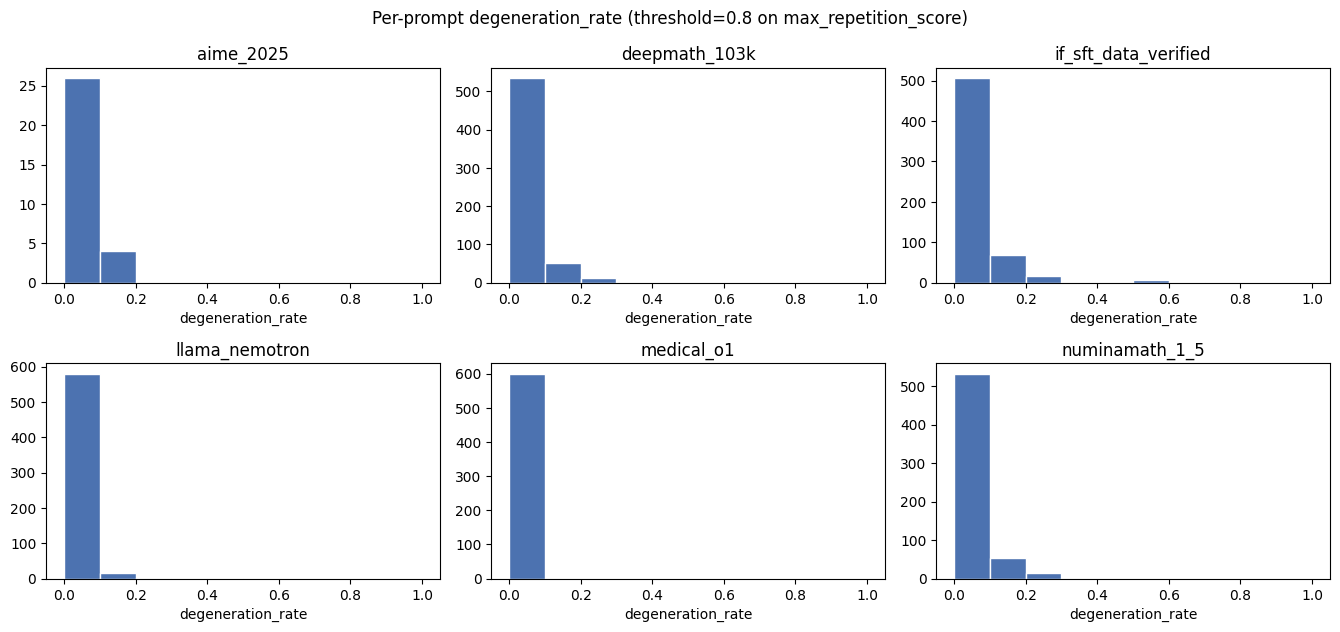

In [50]:
def _hist_grid(values_by_domain, title, xlabel, bins=np.linspace(0, 1, 11)):
    domains_present = list(values_by_domain.keys())
    n = len(domains_present)
    if n == 0:
        print("No domains available yet.")
        return
    ncols = min(3, n)
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), squeeze=False)
    for ax, domain in zip(axes.flat, domains_present):
        ax.hist(values_by_domain[domain].dropna(), bins=bins, color="#4C72B0", edgecolor="white")
        ax.set_title(domain)
        ax.set_xlabel(xlabel)
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- repetition: prompt-level degeneration_rate (thresholded, from prompt_stats.parquet) ---
if not prompt_stats_df.empty:
    degeneration_summary = (
        prompt_stats_df.groupby("domain")["degeneration_rate"]
        .agg(mean_degeneration_rate="mean", max_degeneration_rate="max", n_prompts="count")
    )
    display(degeneration_summary)
    _hist_grid(
        {d: prompt_stats_df.loc[prompt_stats_df["domain"] == d, "degeneration_rate"] for d in degeneration_summary.index},
        f"Per-prompt degeneration_rate (threshold={label_module.DEFAULT_DEGENERATION_THRESHOLD} on max_repetition_score)",
        "degeneration_rate",
    )
else:
    print("prompt_stats.parquet not available yet.")

,lrs_match_rate,n_rollouts
domain,,
aime_2025,0.960000,300
deepmath_103k,0.902333,6000
if_sft_data_verified,0.540000,6000
llama_nemotron,0.825000,6000
medical_o1,0.202333,6000
numinamath_1_5,0.837833,6000


20133/30300 rollouts have an LRS repeat of >= 10 tokens.


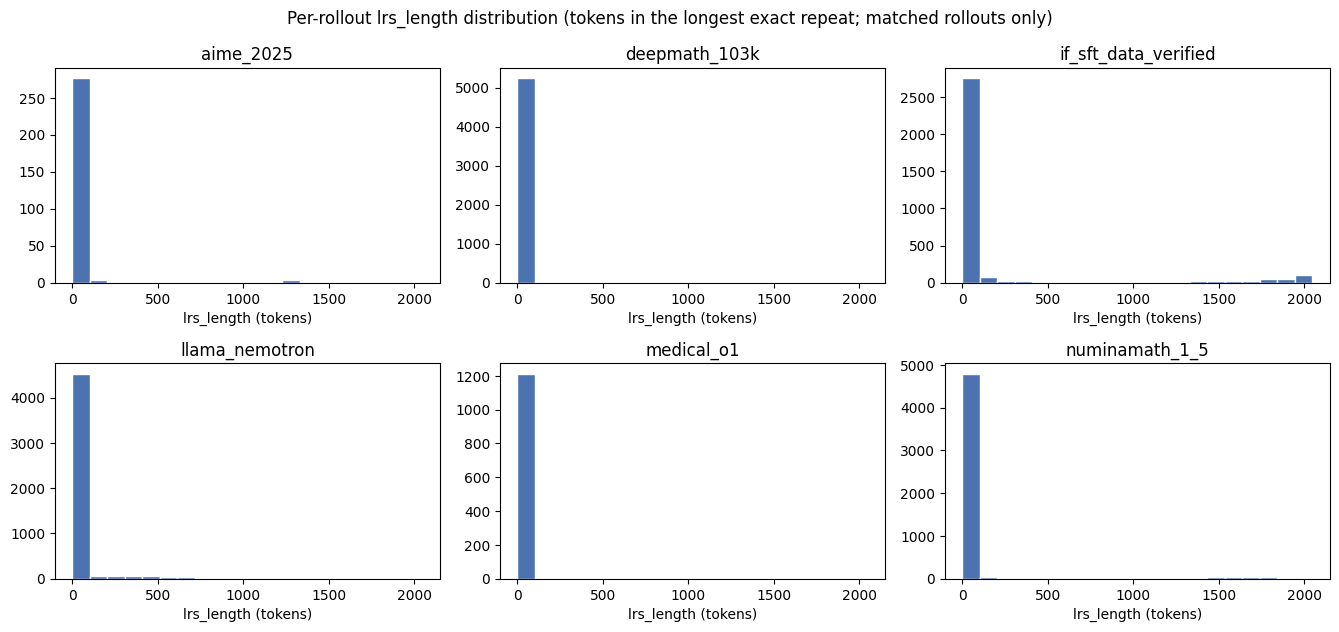

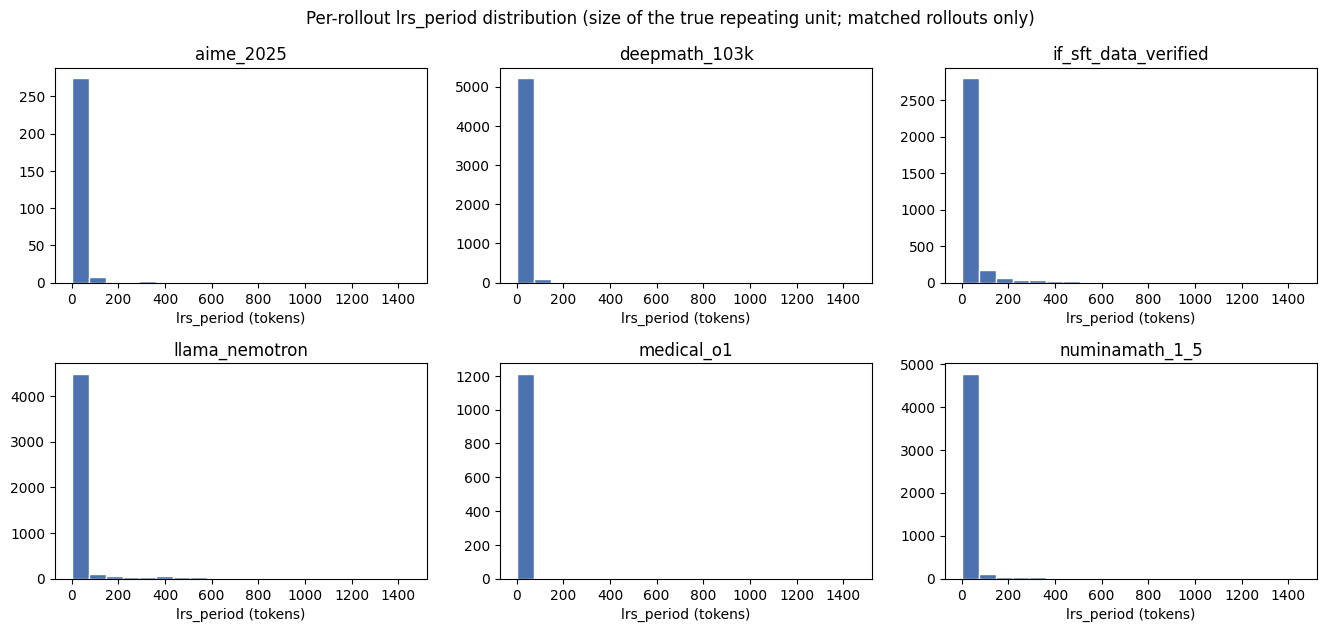

In [51]:
# --- LRS: whole-rollout exact-repeat match, per domain (no fixed threshold) ---
if not rollout_signal_df.empty:
    lrs_match_summary = (
        rollout_signal_df.groupby("domain")["has_lrs_match"]
        .agg(lrs_match_rate="mean", n_rollouts="count")
    )
    display(lrs_match_summary)

    matched = rollout_signal_df[rollout_signal_df["has_lrs_match"]]
    print(f"{len(matched)}/{len(rollout_signal_df)} rollouts have an LRS repeat of >= "
          f"{label_module.DEFAULT_LRS_MIN_LENGTH} tokens.")

    if not matched.empty:
        length_bins = np.linspace(0, matched["lrs_length"].max(), 21)
        _hist_grid(
            {d: matched.loc[matched["domain"] == d, "lrs_length"] for d in lrs_match_summary.index},
            "Per-rollout lrs_length distribution (tokens in the longest exact repeat; matched rollouts only)",
            "lrs_length (tokens)",
            bins=length_bins,
        )

        # lrs_period: the *actual* repeating unit size -- distinguishes "one word spammed
        # forever" (period ~= 1) from "one long paragraph repeated twice" (period ~= lrs_length),
        # which can otherwise look identical in lrs_length alone.
        period_bins = np.linspace(0, matched["lrs_period"].max(), 21)
        _hist_grid(
            {d: matched.loc[matched["domain"] == d, "lrs_period"] for d in lrs_match_summary.index},
            "Per-rollout lrs_period distribution (size of the true repeating unit; matched rollouts only)",
            "lrs_period (tokens)",
            bins=period_bins,
        )
else:
    print("No labeled domains available yet.")

,mean,max,min
domain,,,
aime_2025,0.427700,0.966822,0.016300
deepmath_103k,0.414214,1.317496,0.012662
if_sft_data_verified,0.617717,4.593693,0.004877
llama_nemotron,0.435042,1.097740,0.006070
medical_o1,0.818040,1.641292,0.073178
numinamath_1_5,0.373331,1.347791,0.006872


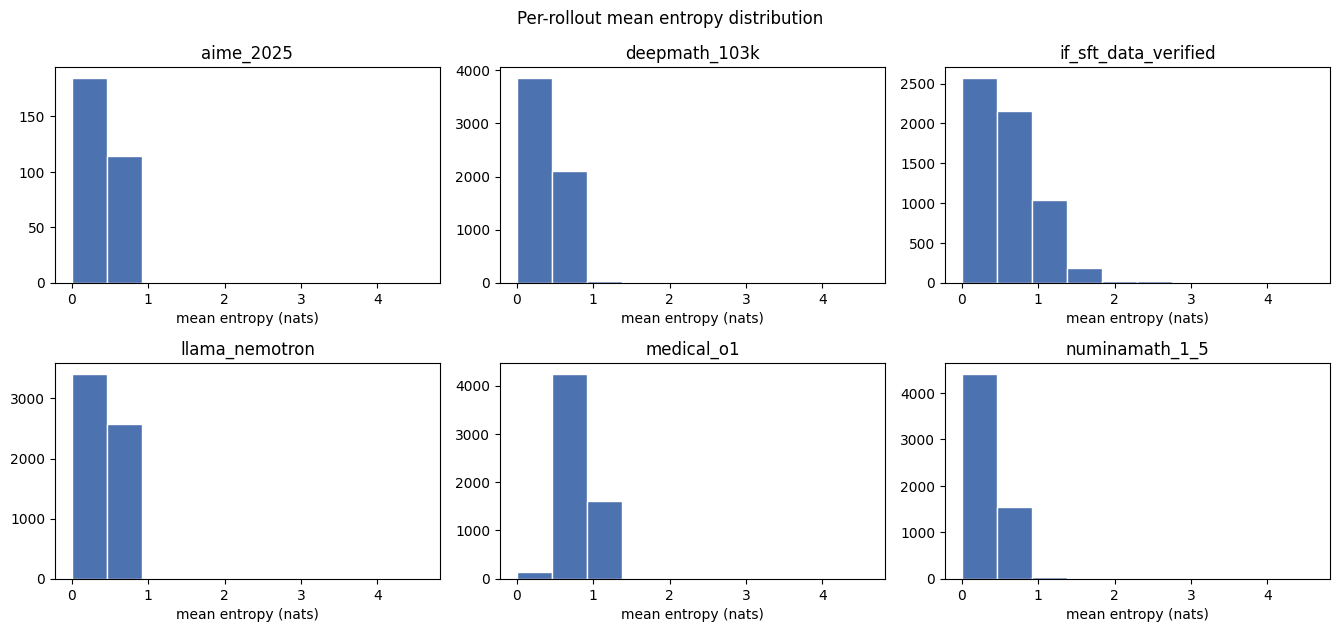

In [52]:
# --- Entropy: per-rollout mean entropy distribution ---
if not rollout_signal_df.empty:
    entropy_summary = (
        rollout_signal_df.groupby("domain")["mean_entropy"]
        .agg(mean="mean", max="max", min="min")
    )
    display(entropy_summary)
    entropy_vals = rollout_signal_df["mean_entropy"]
    entropy_bins = np.linspace(entropy_vals.min(), entropy_vals.max(), 11)
    _hist_grid(
        {d: rollout_signal_df.loc[rollout_signal_df["domain"] == d, "mean_entropy"] for d in entropy_summary.index},
        "Per-rollout mean entropy distribution",
        "mean entropy (nats)",
        bins=entropy_bins,
    )
else:
    print("No labeled domains available yet.")

In [53]:
# --- length-cap rate: fraction of rollouts that hit max_new_tokens without EOS ---
if not generations_df.empty:
    length_cap_summary = (
        generations_df.assign(hit_cap=generations_df["stop_reason"] == "length")
        .groupby("domain")["hit_cap"]
        .mean()
        .rename("length_cap_rate")
    )
    display(length_cap_summary)
else:
    print("No generated domains available yet.")

domain
aime_2025               0.033333
deepmath_103k           0.026833
if_sft_data_verified    0.060667
llama_nemotron          0.020500
medical_o1              0.000167
numinamath_1_5          0.034333
Name: length_cap_rate, dtype: float64

In [54]:
# --- Does hitting the token cap correlate with degeneration? ---
# Validated finding: hitting the 4096-token generation cap is almost always
# degeneration, not just a long-but-healthy response -- nearly every capped
# rollout has a massive LRS repeat (often a third or more of the whole
# response), vs. a small, likely-benign incidental repeat for normally
# (eos-)terminated rollouts.
if not rollout_signal_df.empty:
    hit_cap = rollout_signal_df["stop_reason"] == "length"
    cap_label = hit_cap.map({False: "eos", True: "hit_cap (length)"})

    crosstab = pd.DataFrame({
        "n_rollouts": rollout_signal_df.groupby(cap_label).size(),
        "lrs_match_rate": rollout_signal_df.groupby(cap_label)["has_lrs_match"].mean(),
        "mean_max_repetition_score": rollout_signal_df.groupby(cap_label)["max_repetition_score"].mean(),
    })
    display(crosstab)

    matched = rollout_signal_df[rollout_signal_df["has_lrs_match"]]
    if not matched.empty:
        matched_cap_label = cap_label.loc[matched.index]
        print("Among matched rollouts, median lrs_length / lrs_period by stop_reason:")
        display(
            matched.groupby(matched_cap_label)[["lrs_length", "lrs_period"]].median()
        )
else:
    print("No labeled domains available yet.")

,n_rollouts,lrs_match_rate,mean_max_repetition_score
stop_reason,,,
eos,29435,0.654663,0.424486
hit_cap (length),865,0.997688,0.692526


Among matched rollouts, median lrs_length / lrs_period by stop_reason:


,lrs_length,lrs_period
stop_reason,,
eos,19.0,19.0
hit_cap (length),1537.0,178.0


## 7. Interactive prompt/rollout explorer

Pick a **domain**, then a **prompt_id** within it, to see per-rollout stats
(how many of its 10 rollouts are repetition-degenerate / have an LRS repeat,
LRS length & period ranges, entropy range, etc.). Then, next to
**Render generation text**: pick a **rollout_idx**, optionally cap how many
leading tokens to display (**max tokens**, -1 or any invalid value shows all
of them), toggle which signals to overlay, and click render.

Two different visual encodings are used, since the two kinds of signal mean
different things (Section 6):

- **`repetition_score`** / **`entropy`** (per-token, continuous) are drawn as
  thin colored underline segments beneath each generated token (one row per
  active signal, gray = undefined/NaN at that position), with a gradient
  legend at the top.
- **LRS repeat** (one whole-rollout match, not per-token) is drawn instead as
  a colored *background* behind the repeating tokens themselves, spanning the
  full recovered repeat span(s) (`lrs_region_starts`/`lrs_region_ends`, which can
  reach beyond the two occurrences the core algorithm originally found, and can
  be more than one disjoint span if the unit is atomic and repeats with
  unrelated content in between rather than back-to-back) -- alternating between
  two shades every `lrs_period` tokens within each span, so the stripes directly
  show how many times the unit repeats. A caption above the render states the
  exact numbers/spans and the decoded repeating unit's text.

The figure is shown inline and saved as both `.png` (quick viewing) and
`.pdf` (reports/papers) under
`notebooks/figures/<domain>/<prompt_id>/rollout_<idx>[_<signals>].{png,pdf}`,
where `<signals>` encodes exactly which checkboxes were on (e.g.
`_repetition-lrs`; omitted entirely if none were checked).

In [55]:
import os

import ipywidgets as widgets
import matplotlib as mpl
from matplotlib.patches import Rectangle
from transformers import AutoTokenizer

FIGURES_DIR = REPO_ROOT / "notebooks" / "figures"

# The tokenizer is only needed to decode individual generated_token_ids for
# Section 7's per-token visualization -- everything else in this notebook
# works off the already-decoded `generated_text` column. Point HF_HOME at the
# same cache generate.py filled in (a different filesystem than REPO_ROOT),
# and load offline since the login node has no guaranteed internet access.
HF_CACHE_DIR = Path(f"/capstor/scratch/cscs/{os.environ['USER']}/degeneration-probe/hf_cache")
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR))
os.environ.setdefault("HF_HUB_CACHE", str(HF_CACHE_DIR))
os.environ.setdefault("HF_HUB_OFFLINE", "1")
TOKENIZER = AutoTokenizer.from_pretrained(config.model_name, local_files_only=True)

# --- per-token continuous metrics: color scale + legend text for each signal ---
# LRS is deliberately NOT in here -- it's one whole-rollout match, not a per-token
# array, so it gets its own background-highlight treatment below instead of an
# underline row (see METRIC_SPECS docstring-equivalent note in Section 7's intro cell).
METRIC_SPECS = {
    "repetition_score": dict(
        short="repetition", cmap="Reds", vmin=0.0, vmax=1.0,
        label="repetition_score  (1 - bigram TTR, 256-token window; 0=diverse -> 1=fully repetitive; degeneration threshold=0.8)",
    ),
    "entropy": dict(
        short="entropy", cmap="Blues", vmin=0.0, vmax=None,
        label="entropy  (next-token Shannon entropy, nats, pre-temperature/top-p; darker=more uncertain; scale is per-rendering)",
    ),
}

# Two alternating shades used to highlight the LRS repeat region: one swatch per
# lrs_period-token unit, so consecutive repeats are visually distinguishable.
_LRS_STRIPE_COLORS = [mpl.colormaps["Purples"](0.35), mpl.colormaps["Purples"](0.60)]


def _display_token_text(text):
    """Make a decoded token's text safe to lay out as a single monospace cell."""
    text = text.replace("\n", "↵").replace("\r", "↵").replace("\t", "→")
    return text if text else "·"  # zero-width decode (rare) -> visible placeholder


def _wrap_tokens(token_texts, wrap_width):
    """Greedily pack decoded token strings into lines of <= wrap_width columns.

    Returns a list of lines; each line is a list of (token_pos, text, start_col, end_col),
    token_pos indexing into the (possibly truncated) displayed token sequence.
    """
    lines, current, col = [], [], 0
    for pos, text in enumerate(token_texts):
        width = len(text)
        if current and col + width > wrap_width:
            lines.append(current)
            current, col = [], 0
        current.append((pos, text, col, col + width))
        col += width
    lines.append(current)
    return lines


def _token_color(value, cmap, vmin, vmax):
    if value is None or np.isnan(value):
        return (0.55, 0.55, 0.55, 1.0)  # gray: undefined/NaN for this position
    norm = 0.0 if vmax <= vmin else (value - vmin) / (vmax - vmin)
    return mpl.colormaps[cmap](min(max(norm, 0.0), 1.0))


def _measure_char_width_axes_fraction(fig, ax, fontsize):
    """axes-fraction width of one monospace character, measured via the real renderer."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    probe = ax.text(0, 0, "M" * 40, family="monospace", fontsize=fontsize, transform=ax.transAxes, alpha=0)
    char_px = probe.get_window_extent(renderer=renderer).width / 40
    probe.remove()
    return char_px / ax.get_window_extent(renderer=renderer).width


def render_generation_figure(
    domain, prompt_id, rollout_idx,
    show_repetition=True, show_lrs_region=True, show_entropy=True,
    max_tokens=-1,
    wrap_width=110, fontsize=8.5,
):
    prompt_row = prompts_df.loc[prompts_df["prompt_id"] == prompt_id].iloc[0]
    gen_row = generations_df.loc[
        (generations_df["prompt_id"] == prompt_id) & (generations_df["rollout_idx"] == rollout_idx)
    ].iloc[0]
    label_match = labels_df.loc[
        (labels_df["prompt_id"] == prompt_id) & (labels_df["rollout_idx"] == rollout_idx)
    ]
    label_row = label_match.iloc[0] if not label_match.empty else None

    token_ids = [int(t) for t in gen_row["generated_token_ids"]]
    num_tokens_total = len(token_ids)

    if max_tokens == -1:
        n_display = num_tokens_total
        max_tokens_note = None
    elif isinstance(max_tokens, (int, np.integer)) and 1 <= max_tokens <= num_tokens_total:
        n_display = max_tokens
        max_tokens_note = None
    else:
        n_display = num_tokens_total
        max_tokens_note = (
            f"max_tokens={max_tokens!r} is invalid (must be -1, or an integer in "
            f"[1, {num_tokens_total}]) -- showing all {num_tokens_total} tokens."
        )

    display_ids = token_ids[:n_display]
    token_texts = [
        _display_token_text(TOKENIZER.decode([tid], skip_special_tokens=False)) for tid in display_ids
    ]

    active_metrics = [
        key for key, show in (
            ("repetition_score", show_repetition),
            ("entropy", show_entropy),
        )
        if show and label_row is not None
    ]
    metric_arrays, metric_vrange = {}, {}
    for key in active_metrics:
        arr = np.asarray(label_row[key], dtype=float)[:n_display]
        spec = METRIC_SPECS[key]
        vmin = spec["vmin"]
        vmax = spec["vmax"]
        if vmax is None:  # entropy: no fixed [0, 1] range -- scale to what's actually shown
            finite = arr[~np.isnan(arr)]
            vmax = max(float(finite.max()), vmin + 1e-6) if finite.size else vmin + 1e-6
        metric_arrays[key] = arr
        metric_vrange[key] = (vmin, vmax)

    # --- LRS: one whole-rollout match, not a per-token array -- drawn as a background
    # region rather than an underline row. `lrs_region_*` can reach beyond the two
    # occurrences `find_longest_repeated_substring` originally found (see label.py).
    has_lrs_match = label_row is not None and int(label_row["lrs_length"]) > 0
    draw_lrs = show_lrs_region and has_lrs_match
    if draw_lrs:
        period = int(label_row["lrs_period"])
        repeat_count = int(label_row["lrs_period_repeat_count"])
        # Parallel lists, not a single range: the repeating unit can occupy more than
        # one disjoint span (e.g. an atomic phrase repeated twice with unrelated
        # content in between -- see label.py's find_longest_repeated_substring docstring).
        region_starts = [int(s) for s in label_row["lrs_region_starts"]]
        region_ends = [int(e) for e in label_row["lrs_region_ends"]]
        unit_ids = [int(t) for t in label_row["lrs_unit_token_ids"]]
        unit_text = TOKENIZER.decode(unit_ids, skip_special_tokens=False).replace("\n", "↵").replace("\r", "↵")

    prompt_lines = textwrap.wrap(prompt_row["prompt_text"], width=wrap_width) or [""]
    token_lines = _wrap_tokens(token_texts, wrap_width)

    header_lines = [
        f"{prompt_id}  /  rollout_idx={rollout_idx}  /  domain={domain}",
        f"stop_reason={gen_row['stop_reason']}   num_tokens={int(gen_row['num_tokens'])}"
        + (f"   (showing first {n_display}/{num_tokens_total})" if n_display < num_tokens_total else ""),
    ]
    if max_tokens_note:
        header_lines.append(max_tokens_note)
    if draw_lrs:
        max_region_end = max(region_ends)
        region_note = (
            "" if max_region_end <= n_display
            else f"  (extends to token {max_region_end}, beyond what's displayed)"
        )
        spans_text = ", ".join(f"[{s}:{e})" for s, e in zip(region_starts, region_ends))
        header_lines.append(
            f"LRS: {period}-token unit repeated {repeat_count}x across {len(region_starts)} span(s): "
            f"{spans_text}{region_note}"
        )
        header_lines.append(f'  unit: "{textwrap.shorten(unit_text, width=wrap_width - 9, placeholder=" ...")}"')
    elif show_lrs_region and label_row is not None:
        header_lines.append(f"LRS: no repeat found (below the {label_module.DEFAULT_LRS_MIN_LENGTH}-token minimum)")

    # --- figure sizing: sum up vertical "row units" up front, matching the draw pass exactly ---
    LINE_UNIT = 1.0                  # one plain text line (header/prompt/section-label)
    TEXT_TO_SEG_GAP = 0.85           # generated-text line -> its first metric underline row
                                      # (needs to clear the text's own descenders -- anything
                                      # much smaller visibly touches the text)
    SEG_UNIT = 0.34                  # one metric underline row -> the next one (thin bar to
                                      # thin bar, no descenders involved, so these stack tightly)
    NEXT_LINE_GAP_REDUCTION = 0.35   # a generated-text line that follows another one's metric
                                      # underlines doesn't need a FULL LINE_UNIT of headroom --
                                      # nothing above it has descenders to clear -- so shrink
                                      # that specific transition to tighten the visible gap
                                      # between the last underline row and the next line of text
    LEGEND_UNIT = 2.0                # one metric's legend entry: a full label line + a full bar line

    n_metrics = len(active_metrics)
    # LRS gets one more legend entry (label + swatch row), same LEGEND_UNIT budget as a
    # continuous metric, even though it draws no extra per-line row (see below) -- it's
    # only ever drawn as a background behind the SAME text row.
    n_legend_entries = n_metrics + (1 if draw_lrs else 0)
    legend_units = (n_legend_entries * LEGEND_UNIT + 1.0) if (n_metrics or draw_lrs) else 0.0
    n_plain_lines = len(header_lines) + 1 + 1 + len(prompt_lines) + 1 + 1  # + 2 blanks + 2 section labels
    seg_rows_unit = (TEXT_TO_SEG_GAP + max(0, n_metrics - 1) * SEG_UNIT) if n_metrics else 0.0

    n_token_lines = len(token_lines)
    if n_token_lines:
        first_line_unit = LINE_UNIT + seg_rows_unit
        later_text_unit = (LINE_UNIT - NEXT_LINE_GAP_REDUCTION) if n_metrics else LINE_UNIT
        later_line_unit = later_text_unit + seg_rows_unit
        token_lines_total_unit = first_line_unit + max(0, n_token_lines - 1) * later_line_unit
    else:
        token_lines_total_unit = 0.0
    total_units = legend_units + n_plain_lines * LINE_UNIT + token_lines_total_unit

    line_height = 0.16  # inches per unit, monospace font
    fig_height = max(2.0, total_units * line_height + 0.6)
    fig_width = 10.0

    # Prompt/generated text often contains literal "$...$" (e.g. AIME problem
    # statements) -- disable mathtext parsing so it renders as plain text
    # instead of matplotlib trying (and failing) to parse it as LaTeX math.
    with plt.rc_context({"text.parse_math": False}):
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        ax.axis("off")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        char_w = _measure_char_width_axes_fraction(fig, ax, fontsize)
        dy = 1.0 / (total_units + 2)
        y = [1.0]  # mutable cursor (top edge of the next row), shared by nested helpers

        def advance(units):
            y[0] -= units * dy
            return y[0]

        def draw_text(text, bold=False, size=fontsize, x=0.01, ha="left", style="normal"):
            ax.text(
                x, y[0], text, family="monospace", fontsize=size, weight="bold" if bold else "normal",
                style=style, ha=ha, va="top", transform=ax.transAxes,
            )

        # --- legend: one entry per active metric (gradient bar), plus one for LRS
        # (alternating-shade swatch) if active. Each entry is TWO full LINE_UNIT-equivalent
        # rows (label, then bar/swatch) so it clears the label's own glyph height -- a
        # half-row gap here visually overlaps the label's descenders instead of sitting
        # cleanly below it.
        if active_metrics or draw_lrs:
            for key in active_metrics:
                spec = METRIC_SPECS[key]
                vmin, vmax = metric_vrange[key]
                advance(1.0)
                draw_text(spec["label"], bold=True)
                bar_top = advance(1.0)
                bar_x0, bar_x1, bar_h = 0.01, 0.35, dy * 0.35
                ax.imshow(
                    np.linspace(0, 1, 256).reshape(1, -1),
                    extent=(bar_x0, bar_x1, bar_top - bar_h, bar_top),
                    transform=ax.transAxes, aspect="auto", cmap=spec["cmap"], vmin=0, vmax=1,
                )
                ax.text(bar_x0 - 0.008, bar_top - bar_h / 2, f"{vmin:.2g}", family="monospace",
                         fontsize=fontsize - 1.5, va="center", ha="right", transform=ax.transAxes)
                ax.text(bar_x1 + 0.008, bar_top - bar_h / 2, f"{vmax:.2g}", family="monospace",
                         fontsize=fontsize - 1.5, va="center", ha="left", transform=ax.transAxes)
            if draw_lrs:
                advance(1.0)
                draw_text(
                    "LRS repeat region  (alternating shades = consecutive repeated token-units; "
                    "see caption above for exact counts)",
                    bold=True,
                )
                swatch_top = advance(1.0)
                swatch_h = dy * 0.35
                n_swatches = 8
                swatch_x0, swatch_x1 = 0.01, 0.35
                swatch_w = (swatch_x1 - swatch_x0) / n_swatches
                for si in range(n_swatches):
                    color = _LRS_STRIPE_COLORS[si % 2]
                    x0 = swatch_x0 + si * swatch_w
                    ax.add_patch(Rectangle(
                        (x0, swatch_top - swatch_h), swatch_w * 0.92, swatch_h,
                        transform=ax.transAxes, facecolor=color, edgecolor="none",
                    ))
            if active_metrics:
                advance(0.5)
                draw_text(
                    "gray segment beneath a token = value undefined (NaN) at that position",
                    style="italic", size=fontsize - 1.5,
                )
            advance(0.5)

        for line in header_lines:
            advance(LINE_UNIT)
            draw_text(line, bold=True)
        advance(LINE_UNIT)  # blank
        advance(LINE_UNIT)
        draw_text("PROMPT:", bold=True)
        for line in prompt_lines:
            advance(LINE_UNIT)
            draw_text(line)
        advance(LINE_UNIT)  # blank
        advance(LINE_UNIT)
        draw_text("GENERATED TEXT:", bold=True)

        # Each generated-text line's own text needs a full LINE_UNIT of headroom only
        # the first time (it follows the "GENERATED TEXT:" label, ordinary text-to-text
        # spacing) -- every later line follows the PREVIOUS line's metric underlines
        # instead, which have no descenders to clear, so that transition is shrunk by
        # NEXT_LINE_GAP_REDUCTION to keep the underlines snug against both neighbors.
        for i, line in enumerate(token_lines):
            text_unit = LINE_UNIT if (i == 0 or not active_metrics) else LINE_UNIT - NEXT_LINE_GAP_REDUCTION
            text_y = advance(text_unit)
            for pos, text, start_col, end_col in line:
                # LRS region highlight: a background behind the token, drawn in the SAME
                # row as the text itself (not an extra row like the underline metrics
                # below) -- alternates shade every `period` tokens from region_start.
                if draw_lrs:
                    for r_start, r_end in zip(region_starts, region_ends):
                        if r_start <= pos < r_end:
                            stripe_idx = (pos - r_start) // period
                            color = _LRS_STRIPE_COLORS[stripe_idx % 2]
                            x0, x1 = 0.01 + start_col * char_w, 0.01 + end_col * char_w
                            hl_h = dy * LINE_UNIT * 0.85
                            ax.add_patch(Rectangle(
                                (x0, text_y - hl_h), max(x1 - x0, char_w * 0.05), hl_h,
                                transform=ax.transAxes, facecolor=color, edgecolor="none", zorder=1,
                            ))
                            break
                ax.text(0.01 + start_col * char_w, text_y, text, family="monospace", fontsize=fontsize,
                         va="top", transform=ax.transAxes, zorder=2)
            # All active metrics' underlines cluster tightly right below the text: only
            # the first one needs the bigger TEXT_TO_SEG_GAP to clear the text itself,
            # the rest stack with the much tighter SEG_UNIT (bar-to-bar, no glyphs).
            for m_idx, key in enumerate(active_metrics):
                spec = METRIC_SPECS[key]
                vmin, vmax = metric_vrange[key]
                arr = metric_arrays[key]
                seg_top = advance(TEXT_TO_SEG_GAP if m_idx == 0 else SEG_UNIT)
                seg_h = dy * SEG_UNIT * 0.6
                for pos, _text, start_col, end_col in line:
                    color = _token_color(arr[pos], spec["cmap"], vmin, vmax)
                    x0, x1 = 0.01 + start_col * char_w, 0.01 + end_col * char_w
                    pad = min(0.15 * char_w, (x1 - x0) * 0.2)
                    ax.add_patch(Rectangle(
                        (x0 + pad, seg_top - seg_h), max(x1 - x0 - 2 * pad, char_w * 0.05), seg_h,
                        transform=ax.transAxes, facecolor=color, edgecolor="none",
                    ))

        plt.tight_layout()

    metric_shorts = [METRIC_SPECS[k]["short"] for k in active_metrics]
    if draw_lrs:
        metric_shorts.append("lrs")
    suffix = ("_" + "-".join(metric_shorts)) if metric_shorts else ""
    out_dir = FIGURES_DIR / domain / prompt_id
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"rollout_{rollout_idx}{suffix}.png"
    pdf_path = out_dir / f"rollout_{rollout_idx}{suffix}.pdf"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return fig, png_path, pdf_path

In [56]:
domain_options = sorted(rollout_signal_df["domain"].unique()) if not rollout_signal_df.empty else []

domain_dd = widgets.Dropdown(options=domain_options, description="domain:")
prompt_dd = widgets.Dropdown(options=[], description="prompt_id:")

# rollout_idx + the render controls all live together, since they're only
# needed for "Render generation text" (unlike domain/prompt_id, which also
# drive the stats table above).
rollout_dd = widgets.Dropdown(options=[], description="rollout_idx:")
max_tokens_input = widgets.IntText(
    value=-1, description="max tokens:", layout=widgets.Layout(width="150px"),
    tooltip="Number of leading generated tokens to display. -1 (default) or any invalid value shows all tokens.",
)
cb_repetition = widgets.Checkbox(value=True, description="repetition_score", indent=False)
cb_lrs = widgets.Checkbox(value=True, description="LRS repeat (highlight region)", indent=False)
cb_entropy = widgets.Checkbox(value=True, description="entropy", indent=False)
render_btn = widgets.Button(description="Render generation text", button_style="primary")

stats_out = widgets.Output()
render_out = widgets.Output()

THRESHOLD = label_module.DEFAULT_DEGENERATION_THRESHOLD
RENDER_BTN_LABEL = render_btn.description


def _prompt_option_label(prompt_id, sub):
    n_degen = int((sub["max_repetition_score"] > THRESHOLD).sum())
    n_lrs = int(sub["has_lrs_match"].sum())
    return f"{prompt_id}  ({n_degen}/{len(sub)} repetition-degenerate, {n_lrs}/{len(sub)} have an LRS repeat)"


def update_prompts(*_):
    domain = domain_dd.value
    sub = rollout_signal_df[rollout_signal_df["domain"] == domain]
    prompt_ids = sorted(sub["prompt_id"].unique())
    prompt_dd.options = [
        (_prompt_option_label(pid, sub[sub["prompt_id"] == pid]), pid) for pid in prompt_ids
    ]


def update_stats(*_):
    stats_out.clear_output()
    render_out.clear_output()
    prompt_id = prompt_dd.value
    if prompt_id is None:
        rollout_dd.options = []
        return
    sub = rollout_signal_df[rollout_signal_df["prompt_id"] == prompt_id].sort_values("rollout_idx")
    rollout_dd.options = sub["rollout_idx"].tolist()
    with stats_out:
        n = len(sub)
        n_repetition_degen = int((sub["max_repetition_score"] > THRESHOLD).sum())
        matched = sub[sub["has_lrs_match"]]
        n_lrs_match = len(matched)
        print(f"{prompt_id}  (domain={domain_dd.value}, {n} rollouts)")
        print(f"  repetition-degenerate (max_repetition_score > {THRESHOLD}): {n_repetition_degen}/{n}")
        print(f"  LRS repeat found (>= {label_module.DEFAULT_LRS_MIN_LENGTH} tokens): {n_lrs_match}/{n}")
        if not matched.empty:
            print(f"    lrs_length range: {int(matched['lrs_length'].min())} - {int(matched['lrs_length'].max())} tokens")
            print(f"    lrs_period range: {int(matched['lrs_period'].min())} - {int(matched['lrs_period'].max())} tokens")
        print(f"  mean_entropy range         : {sub['mean_entropy'].min():.3f} - {sub['mean_entropy'].max():.3f}")
        print()
        display_df = sub[[
            "rollout_idx", "num_tokens", "stop_reason",
            "max_repetition_score", "has_lrs_match", "lrs_length", "lrs_period", "mean_entropy",
        ]].assign(repetition_degenerate=lambda d: d["max_repetition_score"] > THRESHOLD).set_index("rollout_idx")
        display(display_df)


def on_render_click(_):
    render_out.clear_output()
    domain = domain_dd.value
    prompt_id = prompt_dd.value
    rollout_idx = rollout_dd.value
    if rollout_idx is None:
        with render_out:
            print("Select a rollout_idx first.")
        return

    # Rendering (esp. all signals on a long, untruncated rollout) can take up to
    # ~20s -- disable the button and show a spinner so it doesn't look stuck.
    render_btn.disabled = True
    render_btn.icon = "spinner"
    render_btn.description = "Rendering..."
    with render_out:
        print("Rendering...")
    try:
        fig, png_path, pdf_path = render_generation_figure(
            domain, prompt_id, rollout_idx,
            show_repetition=cb_repetition.value,
            show_lrs_region=cb_lrs.value,
            show_entropy=cb_entropy.value,
            max_tokens=max_tokens_input.value,
        )
        render_out.clear_output()
        with render_out:
            plt.show()
            print(f"Saved PNG: {png_path}")
            print(f"Saved PDF: {pdf_path}")
        plt.close(fig)
    finally:
        render_btn.disabled = False
        render_btn.icon = ""
        render_btn.description = RENDER_BTN_LABEL


domain_dd.observe(update_prompts, names="value")
prompt_dd.observe(update_stats, names="value")
render_btn.on_click(on_render_click)

if domain_options:
    update_prompts()

display(widgets.VBox([
    widgets.HBox([domain_dd, prompt_dd]),
    stats_out,
    widgets.HBox([rollout_dd, max_tokens_input, cb_repetition, cb_lrs, cb_entropy, render_btn]),
    render_out,
]))